In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay

In [12]:
iris = load_iris()
df = pd.DataFrame(data = iris.data,columns = iris.feature_names)
df["species"] = iris.target
df["species"] = df["species"].map({0:"setosa",1:"versicolor",2:"virginica"})

In [21]:
y = df["species"].values
x = iris.data

In [22]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [24]:
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [25]:
test_point = [[6.0, 2.9, 5.1, 1.8]]
pred = model.predict(test_point)

In [27]:
print("Predicted Species is :-" + pred)

['Predicted Species is :-virginica']


In [28]:
accuracy = model.score(x_test,y_test)
print(f"model accuracy is {accuracy * 100:.2f}%")

model accuracy is 100.00%


### Manhattan

In [2]:
iris = load_iris()
x = iris.data[:,:2]

In [3]:
y = iris.target

In [4]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [5]:
model = KNeighborsClassifier(n_neighbors = 3,metric = "manhattan")
model.fit(x_train,y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=3)

In [10]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_pred,y_test)
accuracy*100

80.0

### 20 Newspapers

In [3]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

In [5]:
df = pd.DataFrame({
    "text":newsgroups.data,
    "lables":newsgroups.target
        })

In [6]:
df.head()

,text,lables
0,\n\nI am sure some bashers of Pens fans are pr...,10
1,My brother is in the market for a high-perform...,3
2,\n\n\n\n\tFinally you said what you dream abou...,17
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3
4,1) I have an old Jasmine drive which I cann...,4


In [7]:
vectorizer = TfidfVectorizer(stop_words = "english",max_features = 10000,min_df = 3,max_df = .9)

In [8]:
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))

In [9]:
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

In [10]:
x_raw_train =  train_data.data
x_raw_test = test_data.data

In [11]:
x_train = vectorizer.fit_transform(x_raw_train)
x_test = vectorizer.transform(x_raw_test)

In [12]:
x_train.shape

(11314, 10000)

In [15]:
y_train = train_data.target
y_test = test_data.target

In [16]:
model = KNeighborsClassifier(n_neighbors = 5 ,metric = "cosine")
model.fit(x_train,y_train)

KNeighborsClassifier(metric='cosine')

In [17]:
y_pred_train = model.predict(x_train)
accuracy = accuracy_score(y_train,y_pred_train)
accuracy*100

76.03853632667492

In [68]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
accuracy*100

54.30164630908125

In [74]:
custom_article = ["Researchers have developed a new mRNA-based vaccine that shows promising results in preventing severe cases of viral infections. Clinical trials are ongoing to evaluate its long-term safety and efficacy in different age groups."
]
custom_vec = vectorizer.transform(custom_article)
custom_pred = model.predict(custom_vec)

# Get readable label
print("Predicted Label:", train_data.target_names[custom_pred[0]])


Predicted Label: sci.med


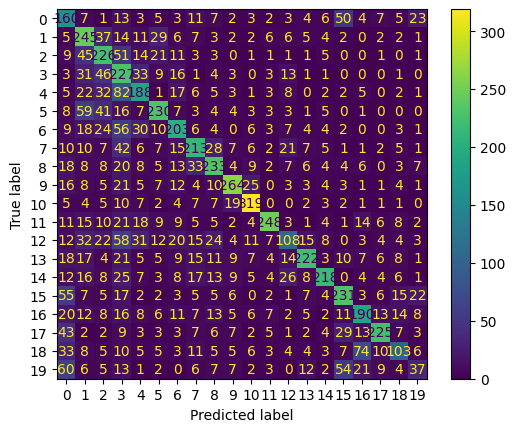

In [78]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()